In [14]:
# Upgrade nilearn and numpy to fix ImportError

# Plot the heatmap of the top regions on a brain surface using nilearn
import numpy as np
import pandas as pd
from nilearn import plotting, datasets
import matplotlib.pyplot as plt
import os

shap_dir = "shap_gcn_results"
# Load SHAP of one fold and repeat
shap_values = np.load(os.path.join(shap_dir, "shap_fold1_rep1.npy"))
# Show the data shape
print("SHAP values shape:", shap_values.shape)

SHAP values shape: (9, 1496, 1)


In [15]:
# Load the shap of all 7 folds and 10 reps
shap_values = []
mean_abs_shap_values_per_model = []
mean_std_shap_values_per_model = []
mean_abs_shap_values_per_subject = []
mean_std_shap_values_per_subject = []

n_nodes = 68
n_feat = 22

for fold in range(1, 8):
    for rep in range(1, 11):

        shap_for_model = np.abs(np.load(os.path.join(shap_dir, f"shap_fold{fold}_rep{rep}.npy")))
        # Calculate mean absolute SHAP values for this model and std
        mean_abs_shap_for_model = np.mean(shap_for_model, axis=0).reshape(n_nodes, n_feat)
        mean_abs_shap_values_per_model.append(mean_abs_shap_for_model)
        shap_values.extend(shap_for_model)

print("SHAP values length:", len(shap_values))
if len(shap_values) > 0:
    print("Shape of one element in shap_values:", np.array(shap_values[0]).shape)

mean_std_shap_values_per_model = np.std(mean_abs_shap_values_per_model, axis=0)
mean_abs_shap_values_per_model = np.mean(mean_abs_shap_values_per_model, axis=0)
mean_abs_shap_values_per_subject = np.mean(shap_values, axis=0).reshape(n_nodes, n_feat)
mean_std_shap_values_per_subject = np.std(shap_values, axis=0).reshape(n_nodes, n_feat)


SHAP values length: 590
Shape of one element in shap_values: (1496, 1)


In [16]:
# List of hemispheres
HEMIS = ["lh", "rh"]
REGION_NAMES = ['bankssts',
'caudalanteriorcingulate',
'caudalmiddlefrontal',
'cuneus',
'entorhinal',
'fusiform',
'inferiorparietal',
'inferiortemporal',
'isthmuscingulate',
'lateraloccipital',
'lateralorbitofrontal',
'lingual',
'medialorbitofrontal',
'middletemporal',
'parahippocampal',
'paracentral',
'parsopercularis',
'parsorbitalis',
'parstriangularis',
'pericalcarine',
'postcentral',
'posteriorcingulate',
'precentral',
'precuneus',
'rostralanteriorcingulate',
'rostralmiddlefrontal',
'superiorfrontal',
'superiorparietal',
'superiortemporal',
'supramarginal',
'frontalpole',
'temporalpole',
'transversetemporal',
'insula'
]
region_keys = [f"{hemi}_{region}" for hemi in HEMIS for region in REGION_NAMES]

# Feature names
FEATURE_NAMES = ['Depth 1', 'Depth 2', 'Depth 3', 'Depth 4', 'Depth 5', 'Depth 6', 'Depth 7', 'Depth 8', 'Depth 9', 'Depth 10',
                 'Depth 11', 'Depth 12', 'Depth 13', 'Depth 14', 'Depth 15', 'Depth 16', 'Depth 17', 'Depth 18', 'Depth 19', 'Depth 20', 'Depth 21',
                'Mean Thickness']

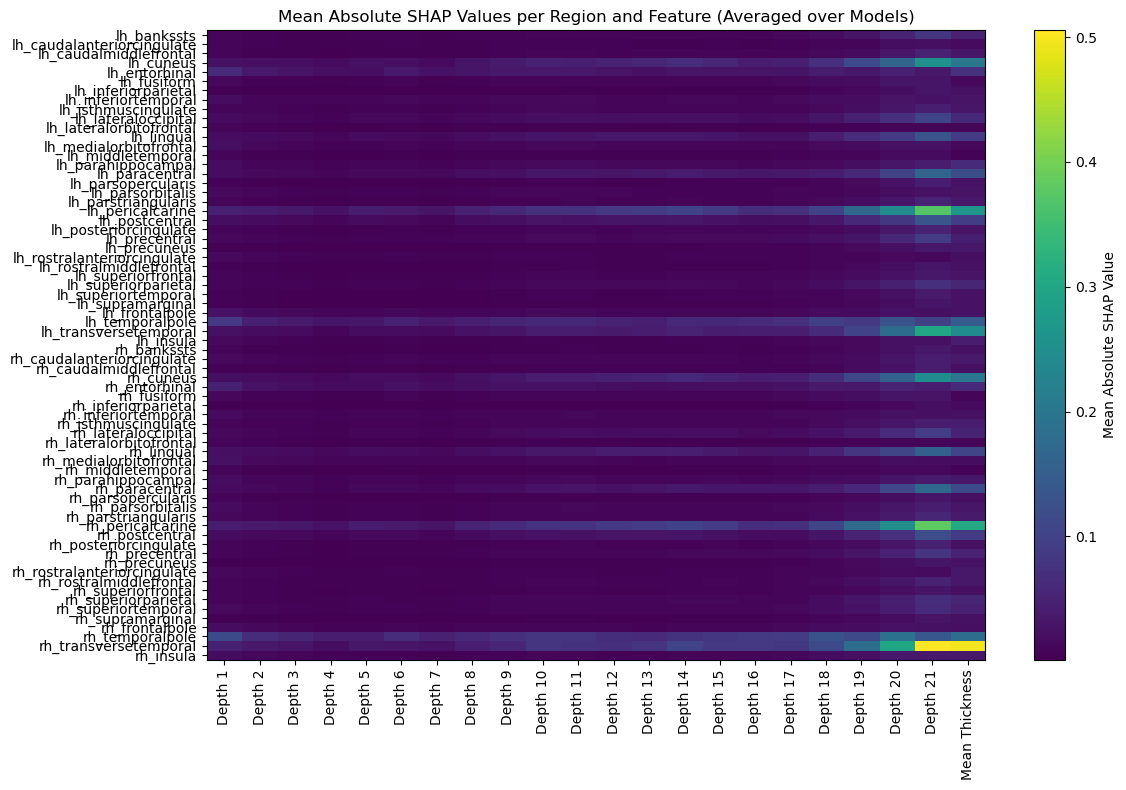

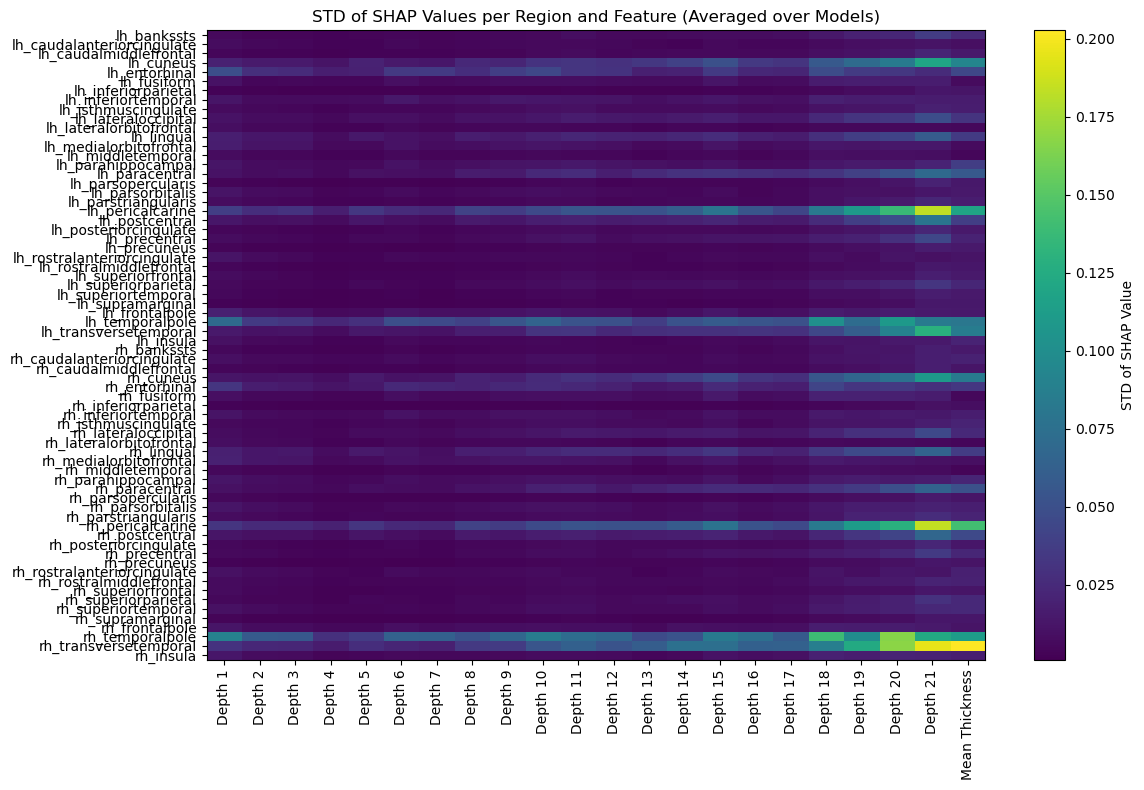

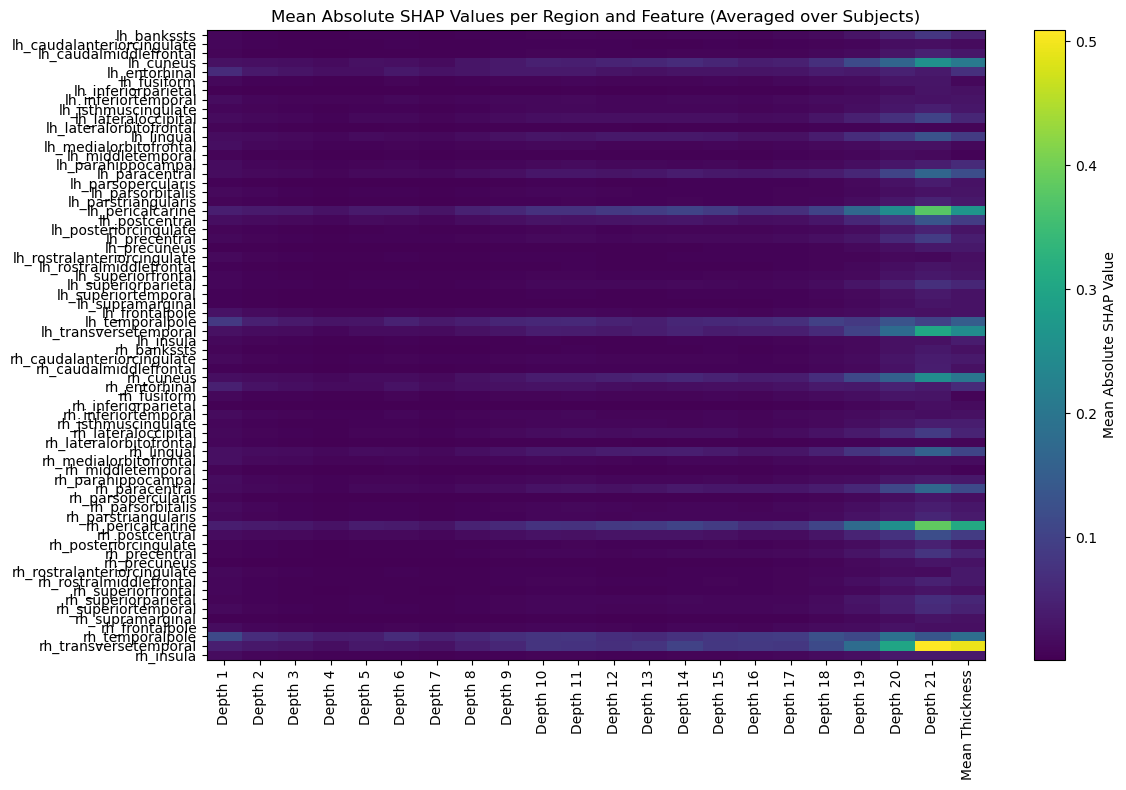

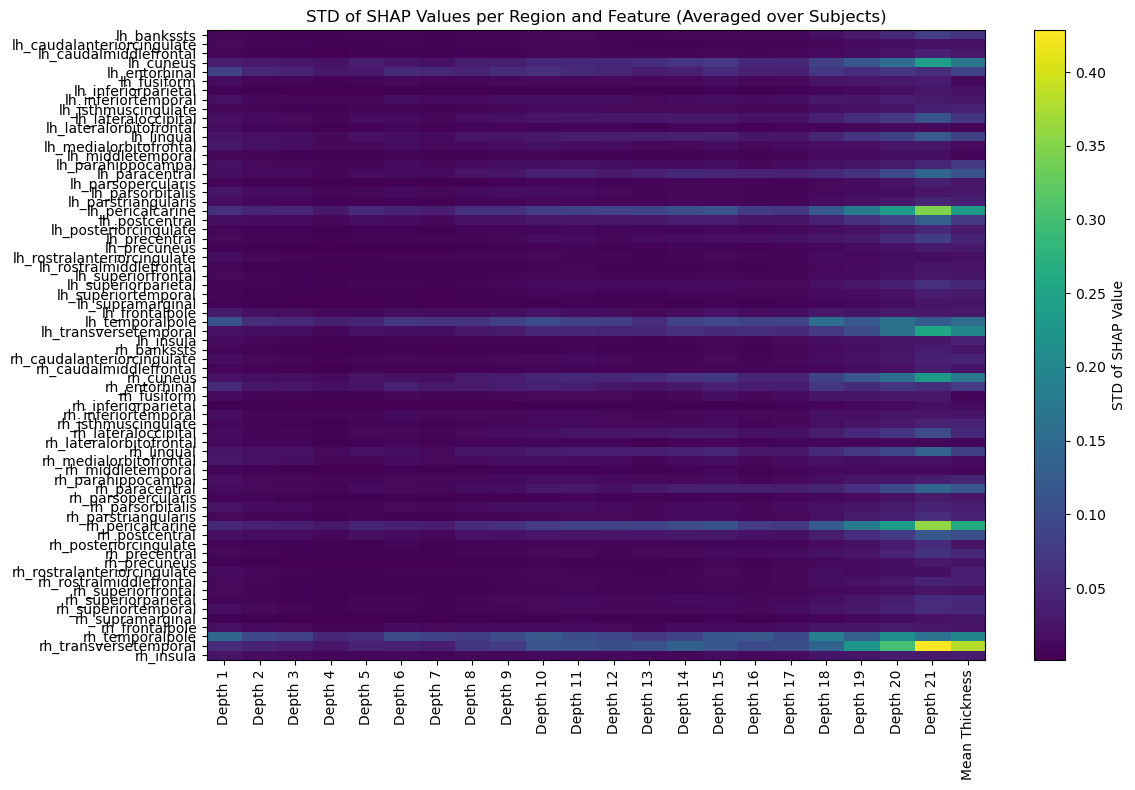

In [17]:
# Display the heatmap of mean absolute SHAP values for each region and feature
# Plot the heatmap of mean absolute SHAP values for each region and feature per model
plt.figure(figsize=(12, 8))
plt.imshow(mean_abs_shap_values_per_model, aspect='auto', cmap='viridis')
plt.colorbar(label='Mean Absolute SHAP Value')
plt.xticks(ticks=np.arange(len(FEATURE_NAMES)), labels=FEATURE_NAMES, rotation=90)
plt.yticks(ticks=np.arange(len(region_keys)), labels=region_keys)
plt.title('Mean Absolute SHAP Values per Region and Feature (Averaged over Models)')
plt.tight_layout()
plt.savefig(os.path.join(shap_dir, "mean_abs_shap_per_model_heatmap.png"))
plt.show()

# Plot the heatmap of std SHAP values for each region and feature per model
plt.figure(figsize=(12, 8))
plt.imshow(mean_std_shap_values_per_model, aspect='auto', cmap='viridis')
plt.colorbar(label='STD of SHAP Value')
plt.xticks(ticks=np.arange(len(FEATURE_NAMES)), labels=FEATURE_NAMES, rotation=90)
plt.yticks(ticks=np.arange(len(region_keys)), labels=region_keys)
plt.title('STD of SHAP Values per Region and Feature (Averaged over Models)')
plt.tight_layout()
plt.savefig(os.path.join(shap_dir, "std_shap_per_model_heatmap.png"))
plt.show()

# Plot the heatmap of mean absolute SHAP values for each region and feature per subject
plt.figure(figsize=(12, 8))
plt.imshow(mean_abs_shap_values_per_subject, aspect='auto', cmap='viridis')
plt.colorbar(label='Mean Absolute SHAP Value')
plt.xticks(ticks=np.arange(len(FEATURE_NAMES)), labels=FEATURE_NAMES, rotation=90)
plt.yticks(ticks=np.arange(len(region_keys)), labels=region_keys)
plt.title('Mean Absolute SHAP Values per Region and Feature (Averaged over Subjects)')
plt.tight_layout()
plt.savefig(os.path.join(shap_dir, "mean_abs_shap_per_subject_heatmap.png"))
plt.show()

# Plot the heatmap of std SHAP values for each region and feature per subject
plt.figure(figsize=(12, 8))
plt.imshow(mean_std_shap_values_per_subject, aspect='auto', cmap='viridis')
plt.colorbar(label='STD of SHAP Value')
plt.xticks(ticks=np.arange(len(FEATURE_NAMES)), labels=FEATURE_NAMES, rotation=90)
plt.yticks(ticks=np.arange(len(region_keys)), labels=region_keys)
plt.title('STD of SHAP Values per Region and Feature (Averaged over Subjects)')
plt.tight_layout()
plt.savefig(os.path.join(shap_dir, "std_shap_per_subject_heatmap.png"))
plt.show()


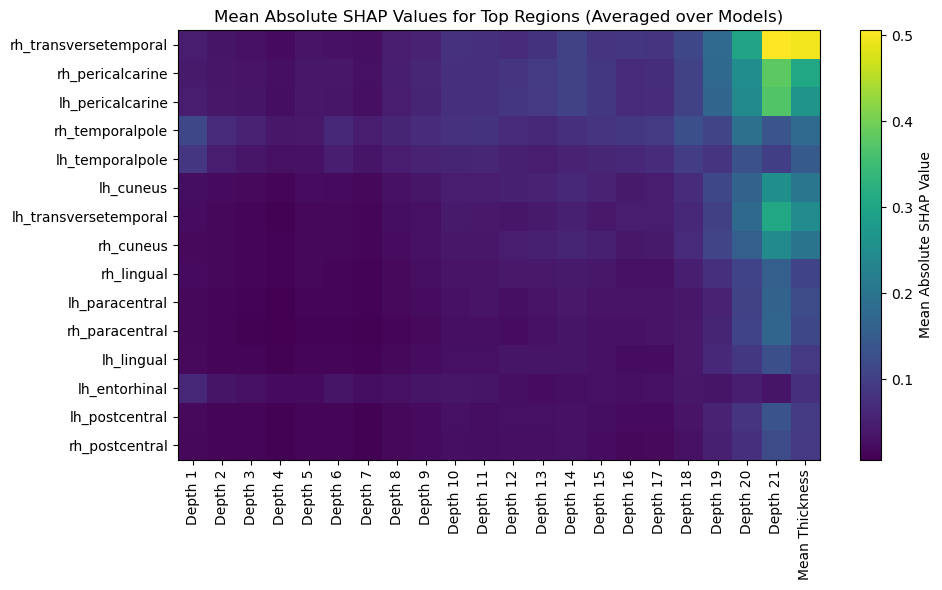

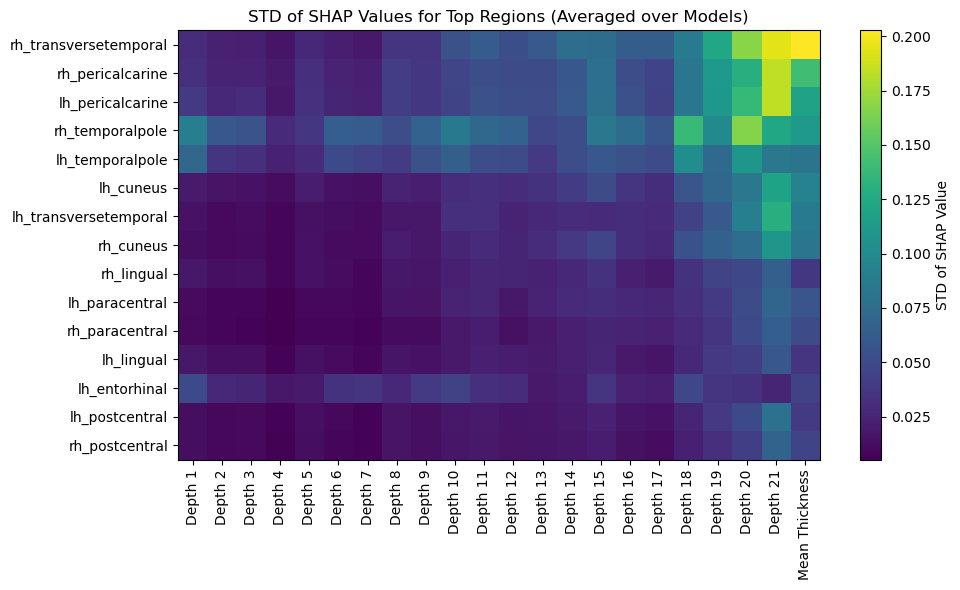

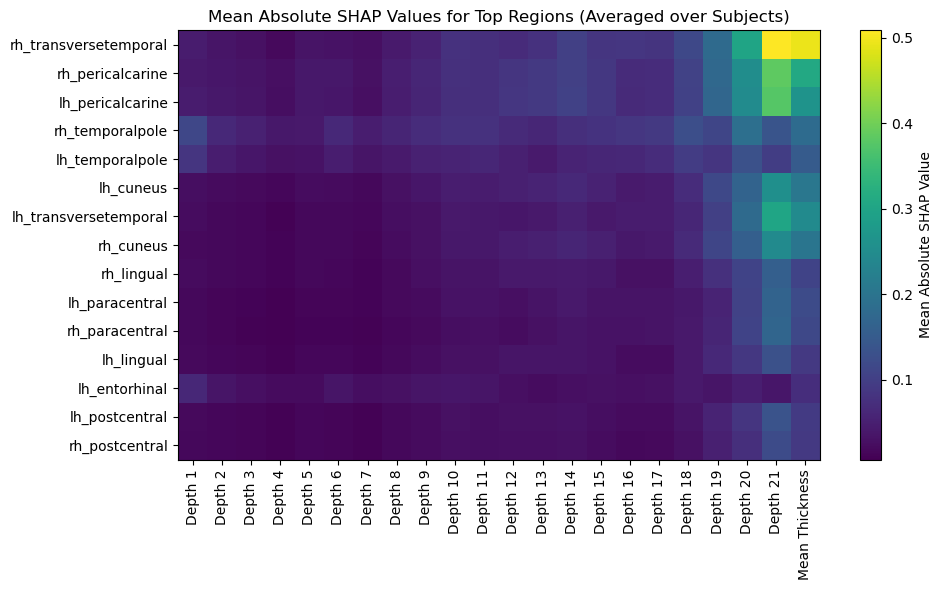

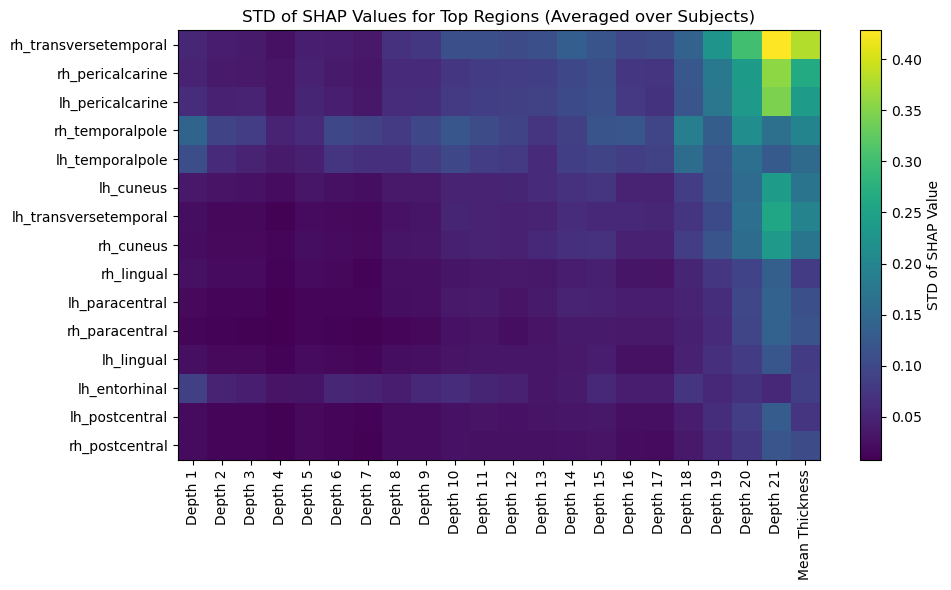

In [18]:
# Top 15 regions
top_regions = ['rh_transversetemporal', 'rh_pericalcarine', 'lh_pericalcarine', 'rh_temporalpole', 'lh_temporalpole',
               'lh_cuneus', 'lh_transversetemporal', 'rh_cuneus', 'rh_lingual', 'lh_paracentral', 'rh_paracentral',
               'lh_lingual', 'lh_entorhinal', 'lh_postcentral', 'rh_postcentral']

# Plot the heatmap of mean absolute SHAP values for the top regions and features per model
plt.figure(figsize=(10, 6))
plt.imshow(mean_abs_shap_values_per_model[[region_keys.index(region) for region in top_regions]], aspect='auto', cmap='viridis')
plt.colorbar(label='Mean Absolute SHAP Value')
plt.xticks(ticks=np.arange(len(FEATURE_NAMES)), labels=FEATURE_NAMES, rotation=90)
plt.yticks(ticks=np.arange(len(top_regions)), labels=top_regions)
plt.title('Mean Absolute SHAP Values for Top Regions (Averaged over Models)')
plt.tight_layout()
plt.savefig(os.path.join(shap_dir, "mean_abs_shap_top_regions_per_model_heatmap.png"))
plt.show()

# Plot the heatmap of std SHAP values for the top regions and features per model
plt.figure(figsize=(10, 6))
plt.imshow(mean_std_shap_values_per_model[[region_keys.index(region) for region in top_regions]], aspect='auto', cmap='viridis')
plt.colorbar(label='STD of SHAP Value')
plt.xticks(ticks=np.arange(len(FEATURE_NAMES)), labels=FEATURE_NAMES, rotation=90)
plt.yticks(ticks=np.arange(len(top_regions)), labels=top_regions)
plt.title('STD of SHAP Values for Top Regions (Averaged over Models)')
plt.tight_layout()
plt.savefig(os.path.join(shap_dir, "std_shap_top_regions_per_model_heatmap.png"))
plt.show()

# Plot the heatmap of mean absolute SHAP values for the top regions and features per subject
plt.figure(figsize=(10, 6))
plt.imshow(mean_abs_shap_values_per_subject[[region_keys.index(region) for region in top_regions]], aspect='auto', cmap='viridis')
plt.colorbar(label='Mean Absolute SHAP Value')
plt.xticks(ticks=np.arange(len(FEATURE_NAMES)), labels=FEATURE_NAMES, rotation=90)
plt.yticks(ticks=np.arange(len(top_regions)), labels=top_regions)
plt.title('Mean Absolute SHAP Values for Top Regions (Averaged over Subjects)')
plt.tight_layout()
plt.savefig(os.path.join(shap_dir, "mean_abs_shap_top_regions_per_subject_heatmap.png"))
plt.show()

# Plot the heatmap of std SHAP values for the top regions and features per subject
plt.figure(figsize=(10, 6))
plt.imshow(mean_std_shap_values_per_subject[[region_keys.index(region) for region in top_regions]], aspect='auto', cmap='viridis')
plt.colorbar(label='STD of SHAP Value')
plt.xticks(ticks=np.arange(len(FEATURE_NAMES)), labels=FEATURE_NAMES, rotation=90)
plt.yticks(ticks=np.arange(len(top_regions)), labels=top_regions)
plt.title('STD of SHAP Values for Top Regions (Averaged over Subjects)')
plt.tight_layout()
plt.savefig(os.path.join(shap_dir, "std_shap_top_regions_per_subject_heatmap.png"))
plt.show()
